In [97]:
import typing as t
from types import ModuleType
from dataclasses import dataclass, field
from hamilton.lifecycle.base import BasePostGraphConstruct
if t.TYPE_CHECKING:
    from hamilton import graph, node

from abc import ABC, abstractmethod


class DeciderExpandableModule(ABC):
    @abstractmethod
    def expand_nodes(self) -> t.Dict[str, "node.Node"]:
        pass

@dataclass
class NamespacedModule(DeciderExpandableModule):
    namespace: str
    expander: DeciderExpandableModule
    def expand_nodes(self) -> t.Dict[str, "node.Node"]:
        pass
        

@dataclass
class DeciderAdaptorHook(BasePostGraphConstruct):
    modules: t.List[DeciderExpandableModule] = field(default_factory=list)

    def add_module(self, mod: DeciderExpandableModule):
        self.modules.append(mod)

    def post_graph_construct(
        self,
        *,
        graph: "graph.FunctionGraph",
        modules: t.List[ModuleType],
        config: t.Dict[str, t.Any],
    ):
        extra_nodes = {}
        for m in self.modules:
            extra_nodes.update(m.expand_nodes())
        graph.nodes = graph.with_nodes(extra_nodes).nodes

In [99]:

import polars as pl

def avg_3wk_spend(spend: pl.Series) -> pl.Series:
    """Rolling 3 week average spend."""
    return spend.rolling_mean(window_size=3)

def acquisition_cost(avg_3wk_spend: pl.Series, signups: pl.Series) -> pl.Series:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: pl.Series) -> float:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: pl.Series, spend_mean: float) -> pl.Series:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: pl.Series) -> float:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: pl.Series, spend_std_dev: float) -> pl.Series:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev


In [39]:
from hamilton import graph, node

class TestAdaptor(DeciderExpandableModule):
    def expand_nodes(self) -> t.Dict[str, node.Node]:
        return {
            "avg_3wk_spend": node.Node.from_fn(avg_3wk_spend),
            "acquisition_cost": node.Node.from_fn(acquisition_cost),
            "spend_mean": node.Node.from_fn(spend_mean),
            "spend_zero_mean": node.Node.from_fn(spend_zero_mean),
            "spend_std_dev": node.Node.from_fn(spend_std_dev),
            "spend_zero_mean_unit_variance": node.Node.from_fn(spend_zero_mean_unit_variance),
        }

In [40]:
from hamilton.driver import Builder
import typing as t

P = t.ParamSpec('P')

class DeciderBuilder(Builder):
    def __init__(self, *args: P.args, **kwargs: P.kwargs) -> None:
        super().__init__(*args, **kwargs)
        self._decider_adaptor = DeciderAdaptorHook()
        self.adapters = [self._decider_adaptor]
    def include(self, module: DeciderExpandableModule, namespace: str|None = None) -> "t.Self":
        if namespace is not None:
            module = NamespacedModule(namespace=namespace, expander=module)
        self._decider_adaptor.add_module(module)
        return self

        

In [41]:


dr = (
    DeciderBuilder()
    .with_config({})
    .include(TestAdaptor())
    .build()
)

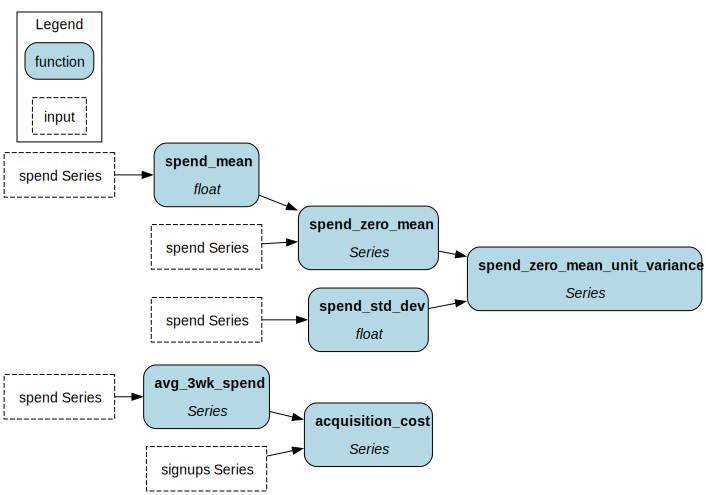

In [42]:
dr

In [50]:
%load_ext hamilton.plugins.jupyter_magic

In [ ]:
%%cell_to_module -m expression_module --display --rebuild-drivers

import polars as pl
from polars.expr import Expr

def avg_3wk_spend(spend: Expr) -> Expr:
    """Rolling 3 week average spend."""
    return spend.rolling_mean(window_size=3)

def acquisition_cost(avg_3wk_spend: Expr, signups: Expr) -> Expr:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: Expr) -> Expr:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: Expr, spend_mean: Expr) -> Expr:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: Expr) -> Expr:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: Expr, spend_std_dev: Expr) -> Expr:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev



In [87]:
pl.Float64

Float64

In [92]:
import inspect
from polars.expr import Expr
from typing import Any, Dict, Optional
from hamilton import lifecycle
from polars._typing import SchemaDefinition

class PolarsAliasAdaptor(lifecycle.NodeExecutionMethod):
    """Adaptor that automatically adds .alias(node_name) to Polars Expr results"""
    
    def run_to_execute_node(
        self,
        *,
        node_name: str,
        node_tags: Dict[str, Any],
        node_callable: Any,
        node_kwargs: Dict[str, Any],
        task_id: Optional[str],
        is_expand: bool,
        is_collect: bool,
        **future_kwargs: Any,
    ) -> Any:
        # Execute the original node
        result = node_callable(**node_kwargs)
        
        # Check if this is a Polars Expr return type
        sig = inspect.signature(node_callable)
        if hasattr(sig, 'return_annotation') and 'Expr' in str(sig.return_annotation):
            # Add .alias(node_name) for Polars expressions
            return result.alias(node_name)
        
        # Return original result for non-Expr types
        return result
    
class MyCustomBuilder(lifecycle.ResultBuilder):
     # add a constructor if you need to
     @staticmethod
     def build_result(**outputs: Dict[str, Expr]) -> pl.LazyFrame:
         """Custom function you fill in"""
         # your logic would go here
         return OBJECT_OF_YOUR_CHOOSING
     

class LazyFrameBuilder(lifecycle.ResultBuilder):
    def __init__(self, input_schema: SchemaDefinition):
        """Add a constructor to accept a base LazyFrame"""
        self.input_schema = input_schema
    
    def build_result(self, **outputs: Dict[str, Expr]) -> pl.LazyFrame:
        """Custom function that combines Polars expressions into a LazyFrame"""
        expressions = list(outputs.values())
        return pl.LazyFrame(schema=self.input_schema).with_columns(expressions).select(*outputs.keys())
        
    # def output_type(self):
    #     return pl.LazyFrame


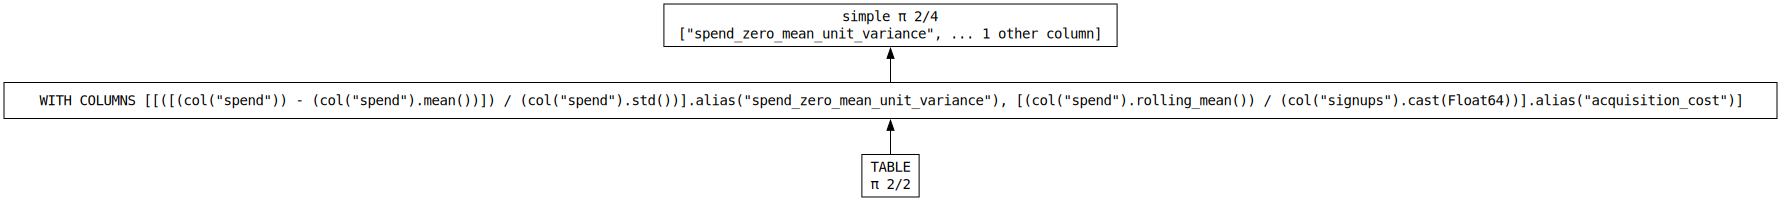

In [96]:
input_schema =  {"spend": pl.Float64, "signups": pl.Int64}
dr = (
    Builder()
    .with_config({})
    .with_modules(expression_module)
    # .with_adapters(PolarsAliasAdaptor(),LazyFrameBuilder())
    .with_adapters(PolarsAliasAdaptor(),LazyFrameBuilder(input_schema))
    # .with_adapters(LazyFrameBuilder(input_schema))
    .build()
)

# all_nodes, input_nodes = dr.graph.get_upstream_nodes(dr.graph.nodes.keys())
# input_data = {n.name: pl.col(n.name) for n in input_nodes}
input_data = {n: pl.col(n) for n in input_schema.keys()}
lazy_frame = dr.execute(final_vars=["spend_zero_mean_unit_variance", "acquisition_cost"], inputs=input_data)
lazy_frame.show_graph()

In [ ]:
from hamilton.driver import Builder

# Test the PolarsAliasAdaptor
test_dr = (
    Builder()
    .with_config({})
    .with_modules(expression_module)
    .with_adapters(PolarsAliasAdaptor())
    .build()
)


{'spend_zero_mean_unit_variance': <Expr ['[([(col("spend")) - (col("spen…'] at 0x3004BB3D0>,
 'acquisition_cost': <Expr ['[(col("spend").rolling_mean().…'] at 0x3004BB9A0>}

In [ ]:
import typing as t
from types import ModuleType
from dataclasses import dataclass, field
from hamilton.lifecycle.base import BasePostGraphConstruct
if t.TYPE_CHECKING:
    from hamilton import graph, node

from abc import ABC, abstractmethod


class DeciderExpandableModule(ABC):
    @abstractmethod
    def expand_nodes(self) -> t.Dict[str, "node.Node"]:
        pass

@dataclass
class NamespacedModule(DeciderExpandableModule):
    namespace: str
    expander: DeciderExpandableModule
    def expand_nodes(self) -> t.Dict[str, "node.Node"]:
        pass

In [1]:

import polars as pl

def avg_3wk_spend(spend: pl.Series) -> pl.Series:
    """Rolling 3 week average spend."""
    return spend.rolling_mean(window_size=3)

def acquisition_cost(avg_3wk_spend: pl.Series, signups: pl.Series) -> pl.Series:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: pl.Series) -> float:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: pl.Series, spend_mean: float) -> pl.Series:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: pl.Series) -> float:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: pl.Series, spend_std_dev: float) -> pl.Series:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev


In [2]:
import sys, os
import typing as t
from hamilton import node

sys.path.insert(0, os.path.abspath(".."))

In [3]:
from decider.dag.core import DeciderExpandableModule

class TestAdaptor(DeciderExpandableModule):
    def expand_nodes(self) -> t.Dict[str, node.Node]:
        return {
            "avg_3wk_spend": node.Node.from_fn(avg_3wk_spend),
            "acquisition_cost": node.Node.from_fn(acquisition_cost),
            "spend_mean": node.Node.from_fn(spend_mean),
            "spend_zero_mean": node.Node.from_fn(spend_zero_mean),
            "spend_std_dev": node.Node.from_fn(spend_std_dev),
            "spend_zero_mean_unit_variance": node.Node.from_fn(spend_zero_mean_unit_variance),
        }

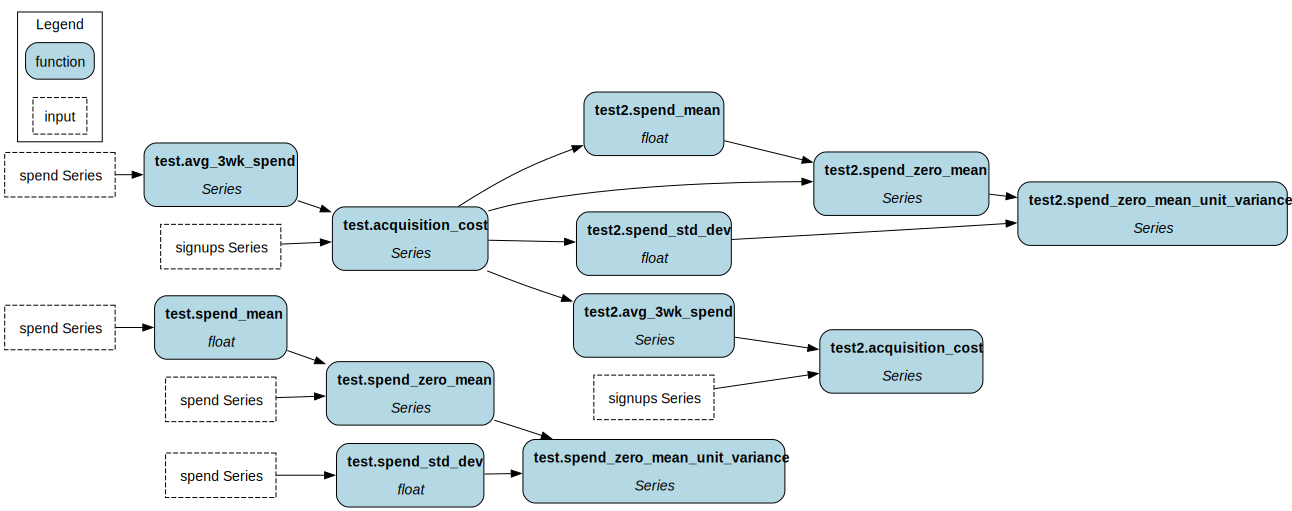

In [5]:
from decider.dag.builder import DeciderBuilder
dr = (
    DeciderBuilder()
    .with_config({})
    .include(TestAdaptor(), namespace="test")
    .include(TestAdaptor(), namespace="test2", parameter_mapping={"test.acquisition_cost":"spend", "test.spend_zero_mean_unit_variance": "test2.spend_zero_mean"})
    .build()
)
dr